In [3]:
import ccxt
import pandas as pd
import os

def download_btc_data():
    print("Connecting to Binance...")
    exchange = ccxt.binance()
    
    all_candles = []
    symbol = 'BTC/USDT'
    timeframe = '1h'
    since = exchange.parse8601('2020-01-01T00:00:00Z')
    
    print("Downloading BTC/USDT hourly data from 2020...")
    while True:
        candles = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
        if not candles:
            break
        all_candles += candles
        since = candles[-1][0] + 1
        print(f"  Downloaded up to: {pd.to_datetime(candles[-1][0], unit='ms').date()}")
        if candles[-1][0] >= exchange.parse8601('2025-01-01T00:00:00Z'):
            break

    df = pd.DataFrame(all_candles, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.drop(columns=['timestamp'])
    df = df[['date', 'open', 'high', 'low', 'close', 'volume']]
    df = df.drop_duplicates(subset='date').reset_index(drop=True)

    os.makedirs('data', exist_ok=True)
    df.to_csv('data/btc_hourly.csv', index=False)
    print(f"\nDone! Saved {len(df)} rows to data/btc_hourly.csv")
    print(f"Date range: {df['date'].min()} → {df['date'].max()}")
    return df

df = download_btc_data()
df.head(10)

Connecting to Binance...
  Downloaded up to: 2020-02-11
  Downloaded up to: 2020-03-24
  Downloaded up to: 2020-05-05
  Downloaded up to: 2020-06-16
  Downloaded up to: 2020-07-27
  Downloaded up to: 2020-09-07
  Downloaded up to: 2020-10-19
  Downloaded up to: 2020-11-29
  Downloaded up to: 2021-01-10
  Downloaded up to: 2021-02-21
  Downloaded up to: 2021-04-04
  Downloaded up to: 2021-05-16
  Downloaded up to: 2021-06-26
  Downloaded up to: 2021-08-07
  Downloaded up to: 2021-09-18
  Downloaded up to: 2021-10-29
  Downloaded up to: 2021-12-10
  Downloaded up to: 2022-01-21
  Downloaded up to: 2022-03-03
  Downloaded up to: 2022-04-14
  Downloaded up to: 2022-05-26
  Downloaded up to: 2022-07-06
  Downloaded up to: 2022-08-17
  Downloaded up to: 2022-09-28
  Downloaded up to: 2022-11-08
  Downloaded up to: 2022-12-20
  Downloaded up to: 2023-01-31
  Downloaded up to: 2023-03-13
  Downloaded up to: 2023-04-24
  Downloaded up to: 2023-06-05
  Downloaded up to: 2023-07-16
  Downloaded u

,date,open,high,low,close,volume
0,2020-01-01 00:00:00,7195.24,7196.25,7175.46,7177.02,511.814901
1,2020-01-01 01:00:00,7176.47,7230.00,7175.71,7216.27,883.052603
2,2020-01-01 02:00:00,7215.52,7244.87,7211.41,7242.85,655.156809
3,2020-01-01 03:00:00,7242.66,7245.00,7220.00,7225.01,783.724867
4,2020-01-01 04:00:00,7225.00,7230.00,7215.03,7217.27,467.812578
5,2020-01-01 05:00:00,7217.26,7229.76,7216.65,7224.21,344.670596
6,2020-01-01 06:00:00,7224.24,7236.27,7221.51,7225.62,621.467023
7,2020-01-01 07:00:00,7225.88,7232.94,7199.11,7209.83,627.344854
8,2020-01-01 08:00:00,7209.83,7210.00,7180.00,7200.64,915.545974
9,2020-01-01 09:00:00,7200.29,7210.51,7188.00,7188.77,636.386102


Total rows: 44,000
Date range: 2020-01-01 00:00:00 → 2025-01-08 15:00:00
Missing values: 0


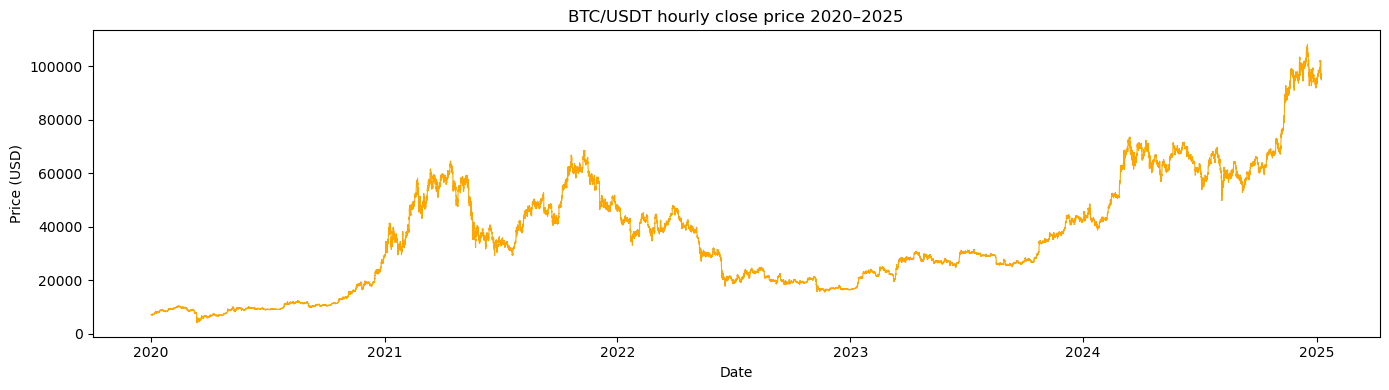

In [5]:
import matplotlib.pyplot as plt

df = pd.read_csv('data/btc_hourly.csv', parse_dates=['date'])

print(f"Total rows: {len(df):,}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Missing values: {df.isnull().sum().sum()}")

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['close'], linewidth=0.8, color='orange')
plt.title('BTC/USDT hourly close price 2020–2025')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()